In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
df = pd.read_csv("./Dataset/train.csv")
df.columns = df.columns.str.strip().str.lower()
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [11]:
df = df[df["store_nbr"] == 1]             
df = df[df["family"] == "BEVERAGES"]

In [13]:
df = df.groupby("date")["sales"].sum().reset_index()

In [14]:
df["sales"] = df["sales"].astype(float)
df["lag1"] = df["sales"].shift(1)
df["lag2"] = df["sales"].shift(2)
df["lag3"] = df["sales"].shift(3)
df["lag7"] = df["sales"].shift(7)
df = df.dropna()

In [15]:
X = df[["lag1", "lag2", "lag3", "lag7"]]
y = df["sales"]

In [16]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [17]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, random_state=42)

In [18]:
y_pred = model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 358.75275084407633


In [21]:
future_steps = 7
last_data = df["sales"].values[-7:].tolist()

future_predictions = []

for i in range(future_steps):
    input_data = np.array([
        last_data[-1],  # lag1
        last_data[-2],  # lag2
        last_data[-3],  # lag3
        last_data[-7]   # lag7
    ]).reshape(1, -1)

    pred = model.predict(input_data)[0]

    future_predictions.append(pred)
    last_data.append(pred)

print("\nPrediksi 7 hari ke depan:")
for i, val in enumerate(future_predictions):
    print(f"Hari +{i+1}: {val:.2f}")


Prediksi 7 hari ke depan:
Hari +1: 2195.76
Hari +2: 2175.12
Hari +3: 1006.13
Hari +4: 2018.36
Hari +5: 1834.41
Hari +6: 2138.21
Hari +7: 1967.20


d:\Machine Learning\environments\deep_learning\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Machine Learning\environments\deep_learning\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Machine Learning\environments\deep_learning\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Machine Learning\environments\deep_learning\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Machine Learning\environments\deep_learning\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestRegressor wa

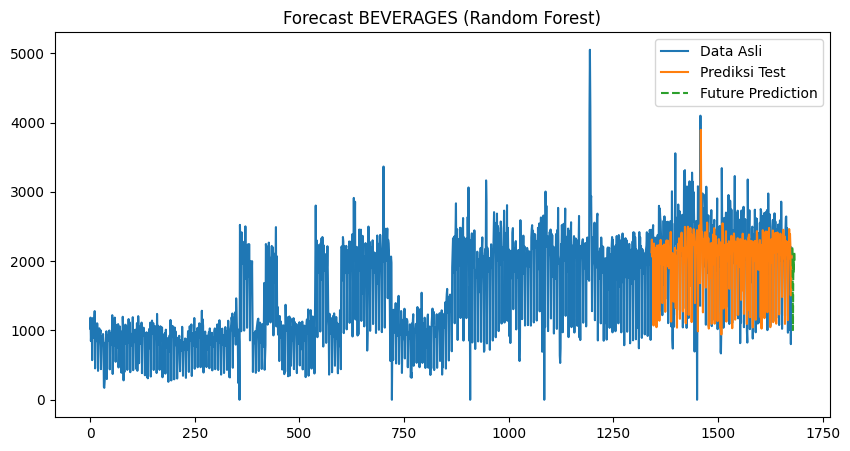

In [22]:
plt.figure(figsize=(10,5))

plt.plot(df["sales"].values, label="Data Asli")

plt.plot(range(split, split + len(y_pred)),
         y_pred, label="Prediksi Test")

plt.plot(range(len(df), len(df) + future_steps),
         future_predictions,
         linestyle="dashed",
         label="Future Prediction")

plt.title("Forecast BEVERAGES (Random Forest)")
plt.legend()
plt.show()